# Hydra Multirun 分析（2026-01-18）

本 notebook 针对 `out/south_china_evolution/2026-01-18/08-48-58` 这次 Hydra 多参数、多重复实验，完成：

- 自动发现参数组合与重复实验（repeats），并检查完整性。
- 从各个参数组合目录下的 `*_tracking.csv` 与 `repeat_*_conversion.csv` 重建整洁数据表。
- 构造 repeat 级别的汇总指标（终态规模、变化幅度、断点等）。
- 使用 `seaborn` 绘制参数面热图、时间演化曲线、分布图等。
- 通过简单但稳健的统计检验（bootstrap / permutation）评估参数效应的稳健性。

> 说明：代码注释与 docstring 使用英文（Google style），便于后续与其他组件集成；markdown 说明则使用中文。

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from src.workflow.analysis import detect_breakpoints

# Global configuration
PROJECT_ROOT = Path("..").resolve()
MULTIRUN_ROOT = PROJECT_ROOT / "out/south_china_evolution/2026-01-18/08-48-58"
EXPECTED_REPEATS = 5

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (8, 5)

MULTIRUN_ROOT

PosixPath('/Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/out/south_china_evolution/2026-01-18/08-48-58')

In [2]:
def parse_job_dir_name(name: str) -> dict:
    """Parse job directory name into metadata.

    The expected pattern is like:
        "0_env.lam_farmer=2,env.lam_ricefarmer=0.1".

    Args:
        name: Directory name produced by Hydra multirun.

    Returns:
        Dict with keys: job_id, lam_farmer, lam_ricefarmer.
    """
    m = re.match(
        r"^(?P<job_id>\d+)_env\.lam_farmer=(?P<lam_farmer>[^,]+),env\.lam_ricefarmer=(?P<lam_ricefarmer>.+)$",
        name,
    )
    if not m:
        raise ValueError(f"Unexpected job dir name: {name}")
    job_id = int(m.group("job_id"))
    lam_farmer = float(m.group("lam_farmer"))
    lam_ricefarmer = float(m.group("lam_ricefarmer"))
    return {
        "job_id": job_id,
        "lam_farmer": lam_farmer,
        "lam_ricefarmer": lam_ricefarmer,
    }


def build_jobs_qc(root: Path, expected_repeats: int = EXPECTED_REPEATS) -> pd.DataFrame:
    """Scan multirun root and build a QC table.

    Each row corresponds to one parameter combination directory.
    """
    rows: list[dict] = []
    for job_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and "env.lam_farmer" in p.name
    ):
        meta = parse_job_dir_name(job_dir.name)
        tracking_files = sorted(job_dir.glob("*_tracking.csv"))
        conversion_files = sorted(job_dir.glob("repeat_*_conversion.csv"))

        tracking_repeat_ids = set()
        for f in tracking_files:
            # e.g. "1_tracking.csv" -> 1
            try:
                repeat_id = int(f.stem.split("_", maxsplit=1)[0])
                tracking_repeat_ids.add(repeat_id)
            except ValueError:
                continue

        conversion_repeat_ids = set()
        for f in conversion_files:
            # e.g. "repeat_1_conversion.csv" -> 1
            m = re.match(r"^repeat_(?P<rid>\d+)_conversion$", f.stem)
            if m:
                conversion_repeat_ids.add(int(m.group("rid")))

        completed_repeats = len(tracking_repeat_ids & conversion_repeat_ids)
        is_complete = completed_repeats == expected_repeats

        rows.append(
            {
                **meta,
                "job_path": job_dir,
                "tracking_count": len(tracking_files),
                "conversion_count": len(conversion_files),
                "completed_repeats": completed_repeats,
                "is_complete": is_complete,
                "tracking_repeat_ids": sorted(tracking_repeat_ids),
                "conversion_repeat_ids": sorted(conversion_repeat_ids),
            }
        )

    jobs_df = (
        pd.DataFrame(rows)
        .sort_values(["lam_farmer", "lam_ricefarmer"])
        .reset_index(drop=True)
    )
    return jobs_df


jobs_qc = build_jobs_qc(MULTIRUN_ROOT)
jobs_qc

,job_id,lam_farmer,lam_ricefarmer,job_path,tracking_count,conversion_count,completed_repeats,is_complete,tracking_repeat_ids,conversion_repeat_ids
0,0,2.0,0.1,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
1,1,2.0,0.2,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
2,2,2.0,0.3,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
3,3,2.0,0.4,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
4,4,2.0,0.5,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
5,5,4.0,0.1,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
6,6,4.0,0.2,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
7,7,4.0,0.3,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
8,8,4.0,0.4,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
9,9,4.0,0.5,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"


In [3]:
# Inspect QC table and visualize completeness

print(f"Found {len(jobs_qc)} job directories under {MULTIRUN_ROOT}.")
jobs_qc.head()

Found 23 job directories under /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/out/south_china_evolution/2026-01-18/08-48-58.


,job_id,lam_farmer,lam_ricefarmer,job_path,tracking_count,conversion_count,completed_repeats,is_complete,tracking_repeat_ids,conversion_repeat_ids
0,0,2.0,0.1,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
1,1,2.0,0.2,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
2,2,2.0,0.3,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
3,3,2.0,0.4,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"
4,4,2.0,0.5,/Users/songshgeo/Documents/CodeBase/Scholar/SC...,5,5,5,True,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]"


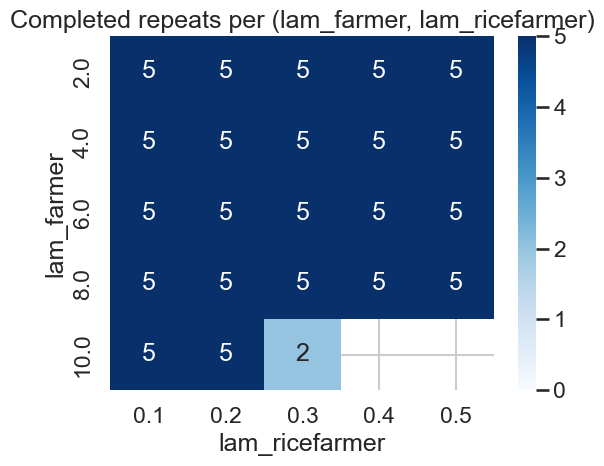

In [4]:
# Completeness heatmap: number of completed repeats per parameter combo

heatmap_data = (
    jobs_qc.pivot_table(
        index="lam_farmer",
        columns="lam_ricefarmer",
        values="completed_repeats",
        aggfunc="max",
    )
    .sort_index(axis=0)
    .sort_index(axis=1)
)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    vmin=0,
    vmax=EXPECTED_REPEATS,
)
ax.set_title("Completed repeats per (lam_farmer, lam_ricefarmer)")
ax.set_xlabel("lam_ricefarmer")
ax.set_ylabel("lam_farmer")
plt.tight_layout()
plt.show()

In [5]:
# Helpers to load tracking and conversion data into tidy tables

from collections.abc import Iterable


def load_tracking_for_job(job_row: pd.Series) -> pd.DataFrame:
    """Load all *_tracking.csv files for a single job directory.

    The result is a long table with metadata columns attached.
    """
    job_path: Path = job_row["job_path"]
    tracking_files = sorted(job_path.glob("*_tracking.csv"))

    frames: list[pd.DataFrame] = []
    for f in tracking_files:
        # e.g. "1_tracking.csv" -> repeat_id = 1
        try:
            repeat_id = int(f.stem.split("_", maxsplit=1)[0])
        except ValueError:
            continue

        df = pd.read_csv(f, index_col=0)
        if "step" not in df.columns:
            # Older runs may store step as index; normalize to a column
            df = df.reset_index().rename(columns={"index": "step"})

        df["job_id"] = job_row["job_id"]
        df["lam_farmer"] = job_row["lam_farmer"]
        df["lam_ricefarmer"] = job_row["lam_ricefarmer"]
        df["repeat_id"] = repeat_id
        frames.append(df)

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def load_all_tracking(jobs: pd.DataFrame, only_complete: bool = True) -> pd.DataFrame:
    """Load tracking data for all jobs into a single long table."""
    frames: list[pd.DataFrame] = []
    for _, row in jobs.iterrows():
        if only_complete and not bool(row["is_complete"]):
            continue
        df = load_tracking_for_job(row)
        if not df.empty:
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


tracking_wide = load_all_tracking(jobs_qc, only_complete=True)
tracking_wide.head()

,step,len_farmers,len_hunters,len_rice,num_farmers,num_hunters,num_rice,len_farmers_n,len_hunters_n,len_rice_n,num_farmers_n,num_hunters_n,num_rice_n,run_id,job_id,lam_farmer,lam_ricefarmer,repeat_id
0,0,0.000000,0.999712,0.000288,0.000000,0.998878,0.001122,0.0,3468,1.0,0.0,185174.0,208.0,1,0,2.0,0.1,1
1,1,0.001725,0.997988,0.000287,0.001357,0.997518,0.001125,6.0,3472,1.0,252.0,185260.0,209.0,1,0,2.0,0.1,1
2,2,0.002297,0.997416,0.000287,0.001786,0.997084,0.001130,8.0,3474,1.0,332.0,185305.0,210.0,1,0,2.0,0.1,1
3,3,0.003724,0.995990,0.000286,0.002886,0.995981,0.001134,13.0,3477,1.0,537.0,185354.0,211.0,1,0,2.0,0.1,1
4,4,0.004577,0.995137,0.000286,0.003425,0.995431,0.001144,16.0,3479,1.0,638.0,185401.0,213.0,1,0,2.0,0.1,1


In [6]:
# Build a tidy long-format table for dynamic plots

if tracking_wide.empty:
    raise RuntimeError(
        "No tracking data loaded; please check MULTIRUN_ROOT and jobs_qc."
    )

value_vars = [
    "num_farmers_n",
    "num_hunters_n",
    "num_rice_n",
]

missing = [v for v in value_vars if v not in tracking_wide.columns]
if missing:
    raise KeyError(f"Missing expected columns in tracking data: {missing}")

tracking_long = tracking_wide.melt(
    id_vars=["job_id", "lam_farmer", "lam_ricefarmer", "repeat_id", "step"],
    value_vars=value_vars,
    var_name="metric",
    value_name="value",
)

metric_to_group = {
    "num_farmers_n": "farmers",
    "num_hunters_n": "hunters",
    "num_rice_n": "rice",
}
tracking_long["group"] = tracking_long["metric"].map(metric_to_group)

tracking_long.head()

,job_id,lam_farmer,lam_ricefarmer,repeat_id,step,metric,value,group
0,0,2.0,0.1,1,0,num_farmers_n,0.0,farmers
1,0,2.0,0.1,1,1,num_farmers_n,252.0,farmers
2,0,2.0,0.1,1,2,num_farmers_n,332.0,farmers
3,0,2.0,0.1,1,3,num_farmers_n,537.0,farmers
4,0,2.0,0.1,1,4,num_farmers_n,638.0,farmers


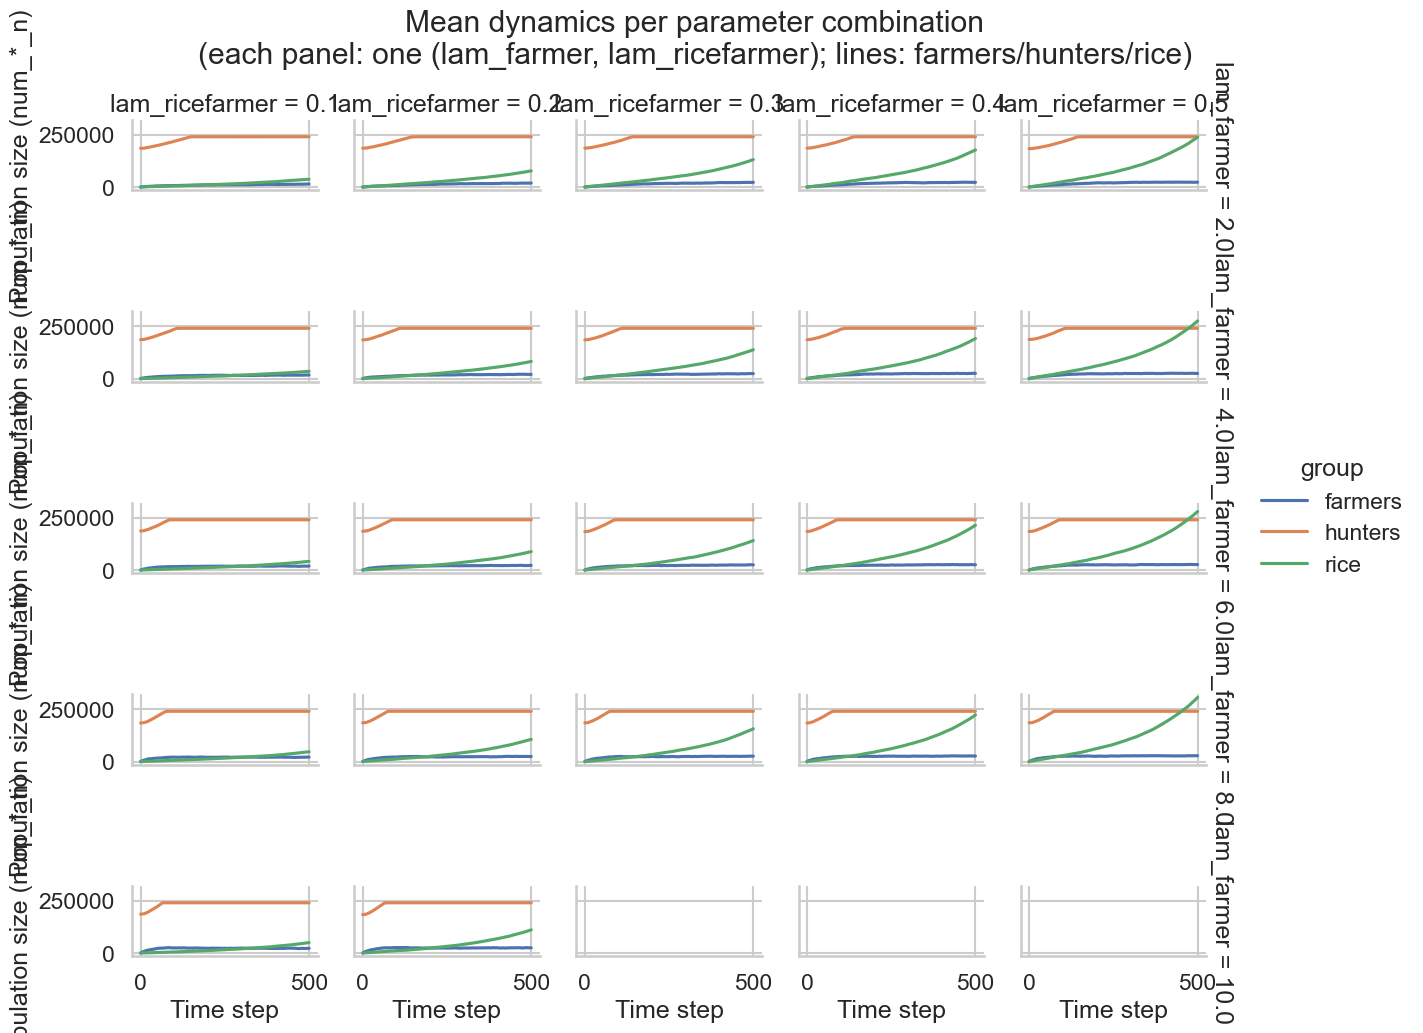

In [7]:
# Mean dynamics per parameter combination (one small subplot per experiment)

agg_dynamic = tracking_long.groupby(
    ["lam_farmer", "lam_ricefarmer", "step", "group"], as_index=False
)["value"].mean()

# Restrict steps if curves are too long; adjust as needed
max_step = agg_dynamic["step"].max()
if max_step > 500:
    agg_dynamic_plot = agg_dynamic.query("step <= 500").copy()
else:
    agg_dynamic_plot = agg_dynamic

g = sns.relplot(
    data=agg_dynamic_plot,
    kind="line",
    x="step",
    y="value",
    hue="group",
    row="lam_farmer",
    col="lam_ricefarmer",
    facet_kws={"margin_titles": True},
    height=2.0,
    aspect=1.3,
)

g.set_axis_labels("Time step", "Population size (num_*_n)")
g.fig.suptitle(
    "Mean dynamics per parameter combination\n"
    "(each panel: one (lam_farmer, lam_ricefarmer); lines: farmers/hunters/rice)",
    y=1.04,
)
plt.show()